In [2]:
!pip install plotly wordcloud scikit-learn pandas numpy matplotlib seaborn

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ----- ---------------------------------- 1.3/9.9 MB 6.1 MB/s eta 0:00:02
   ----------- ---------------------------- 2.9/9.9 MB 7.0 MB/s eta 0:00:02
   ------------------ --------------------- 4.5/9.9 MB 7.1 MB/s eta 0:00:01
   --------------------- ------------------ 5.2/9.9 MB 6.1 MB/s eta 0:00:01
   --------------------------- ------------ 6.8/9.9 MB 6.4 MB/s eta 0:00:01
   --------------------------------- ------ 8.4/9.9 MB 6.6 MB/s eta 0:00:01
   ---------------------------------------  9.7/9.9 MB 6.7 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 6.2 MB/s eta 0:00:00


In [2]:

#Assignment 2 - Safe Report AI: NLP-Based Classification and Prioritisation of Workplace Incident Reports

#Loading of packages and random seed

import re
import warnings
warnings.filterwarnings('ignore')
 
import numpy as np
import pandas as pd

#Visualisation
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from wordcloud import WordCloud

#NLP
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS

#ML utilities
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
import joblib

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120

DATA_PATH    = 'ITA_Case_Detail_Data_2024_through_12-31-2025.csv'

In [4]:
#Data Loading
df_full = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Full dataset shape : {df_full.shape}")

Full dataset shape : (688651, 39)


In [5]:
print(df_full.dtypes.to_string())

ID                          float64
establishment_ID             object
establishment_name           object
ein                          object
company_name                 object
street_address               object
city                         object
state                        object
zip_code                    float64
naics_code                  float64
naics_year                  float64
industry_description         object
establishment_type          float64
size                        float64
annual_average_employees    float64
total_hours_worked          float64
case_number                  object
date_of_incident             object
incident_outcome            float64
dafw_num_away               float64
djtr_num_tr                 float64
type_of_incident            float64
time_started_work            object
time_of_incident             object
time_unknown                float64
date_of_death                object
created_timestamp            object
year_of_filing              

In [6]:
print(df_full.isnull().sum()[df_full.isnull().sum() > 0].to_string())

ID                               1
ein                          60336
company_name                 36378
street_address                   1
city                             1
state                            1
zip_code                         1
naics_code                       1
naics_year                       1
industry_description         52199
establishment_type            1025
size                             1
annual_average_employees         1
total_hours_worked               1
case_number                      9
date_of_incident                29
incident_outcome                 1
dafw_num_away                    1
djtr_num_tr                      1
type_of_incident                 1
time_started_work            75874
time_of_incident             65497
time_unknown                  1181
date_of_death               688449
created_timestamp                1
year_of_filing                   1
job_description                986
SOC_code                         1
SOC_description     

In [7]:
#Removing rows with no usable incident outcome
#incident_outcome is our target — rows where it is missing cannot be used
df_full = df_full.dropna(subset=['incident_outcome'])
df_full['incident_outcome'] = df_full['incident_outcome'].astype(int)
print(f"After dropping missing target: {df_full.shape[0]:,} rows")

After dropping missing target: 688,650 rows


In [8]:
#Stratified sample
SAMPLE_SIZE = 100_000   
#Stratifying sample proportionally from each outcome class
df = (
    df_full
    .groupby('incident_outcome', group_keys=False)
    .apply(lambda x: x.sample(
        n=min(len(x), int(SAMPLE_SIZE * len(x) / len(df_full))),
        random_state=RANDOM_SEED
    ))
    .reset_index(drop=True)
)

df['incident_outcome'] = df['incident_outcome'].astype(int)

print(f"Stratified sample shape : {df.shape}")
print(f"\nOutcome distribution in sample:")
print(df['incident_outcome'].value_counts().sort_index())

Stratified sample shape : (99999, 39)

Outcome distribution in sample:
incident_outcome
1       29
2    35726
3    30211
4    34033
Name: count, dtype: int64


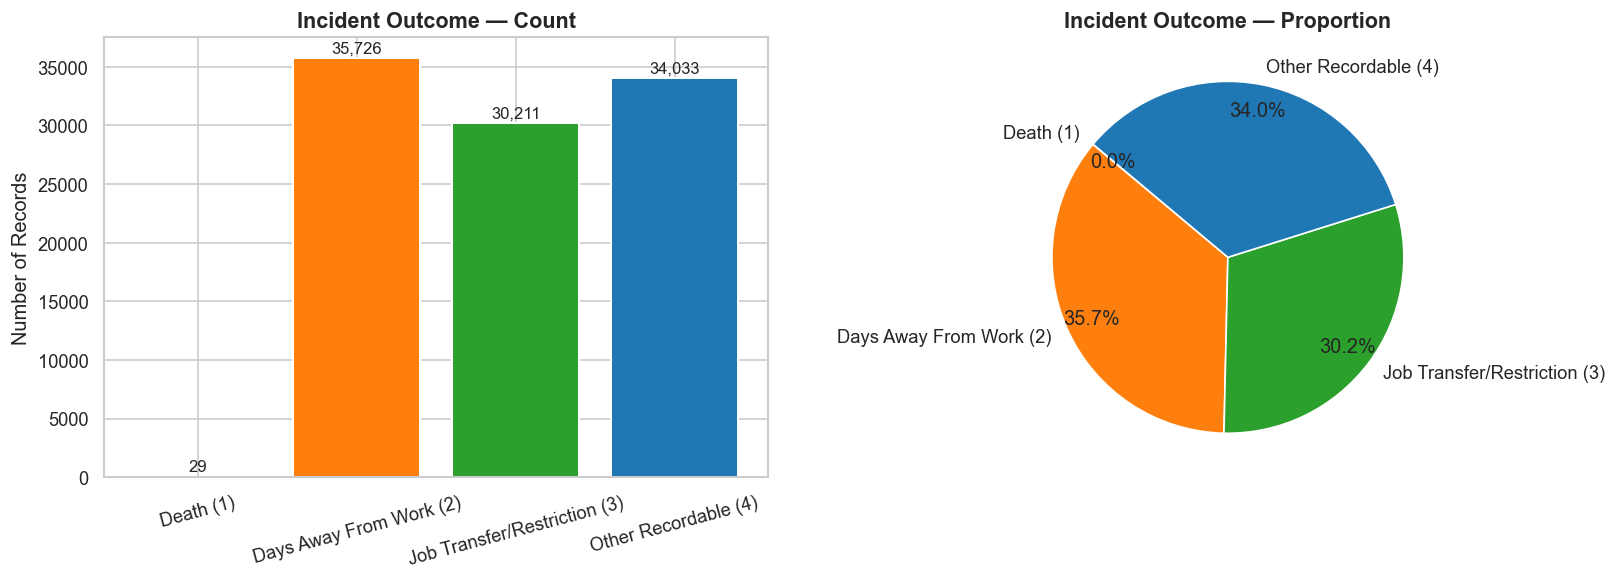

   Deaths account for only 0.03% of records.
   The three major classes (2, 3, 4) are roughly balanced at ~30% each.


In [9]:
#EDA
#Target distribution
outcome_labels = {1: 'Death (1)', 2: 'Days Away From Work (2)',
                  3: 'Job Transfer/Restriction (3)', 4: 'Other Recordable (4)'}
priority_colors = {1: '#d62728', 2: '#ff7f0e', 3: '#2ca02c', 4: '#1f77b4'}

counts = df['incident_outcome'].value_counts().sort_index()
labels = [outcome_labels[i] for i in counts.index]
colors = [priority_colors[i] for i in counts.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Barchart
bars = axes[0].bar(labels, counts.values, color=colors, edgecolor='white', linewidth=1.2)
axes[0].set_title('Incident Outcome — Count', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Records')
axes[0].set_xlabel('')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}', ha='center', va='bottom', fontsize=10)
axes[0].tick_params(axis='x', labelrotation=15)

# Pie chart
axes[1].pie(counts.values, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=140, pctdistance=0.85)
axes[1].set_title('Incident Outcome — Proportion', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"   Deaths account for only {counts[1]/counts.sum()*100:.2f}% of records.")
print(f"   The three major classes (2, 3, 4) are roughly balanced at ~30% each.")

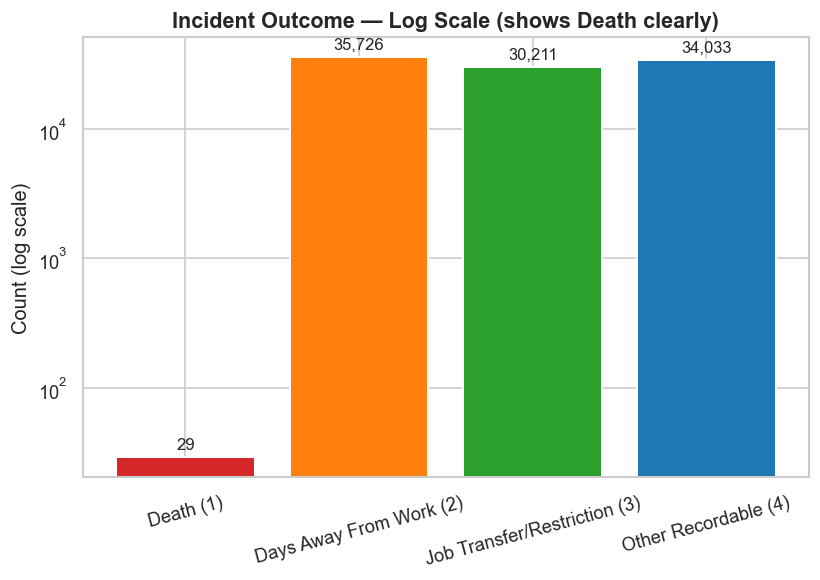

In [10]:
fig2, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(labels, counts.values, color=colors, edgecolor='white', linewidth=1.2)
ax.set_yscale('log')
ax.set_title('Incident Outcome — Log Scale (shows Death clearly)', 
             fontsize=13, fontweight='bold')
ax.set_ylabel('Count (log scale)')
ax.tick_params(axis='x', labelrotation=15)

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.1,
            f'{val:,}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

In [11]:
print("The log scale reveals the Death class (29 cases) which is invisible on a linear scale.")
print("This confirms the severe class imbalance — Deaths are 0.03% of all records.")
print("This is why we group Deaths with DAFW under High Priority rather than treating them separately.")

The log scale reveals the Death class (29 cases) which is invisible on a linear scale.
This confirms the severe class imbalance — Deaths are 0.03% of all records.
This is why we group Deaths with DAFW under High Priority rather than treating them separately.


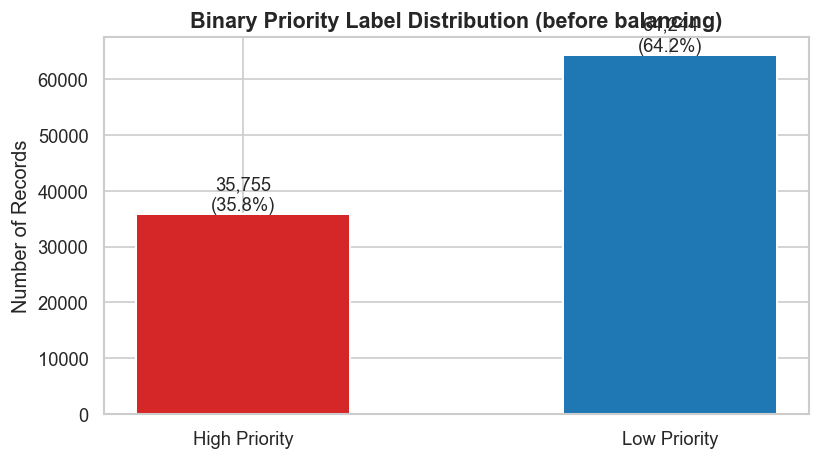

High Priority: 35,755  (35.8%)
Low  Priority: 64,244  (64.2%)


In [12]:
#Binary priority labels

#The four outcome codes into two priority classes that drive the model:
#High Priority = Death (1) + Days Away From Work (2)  
#Low Priority = Job Transfer (3) + Other Recordable (4)

#This binary framing reflects WestMine's core business need that is to flag the most urgent cases immediately.

#Binary label preview (before balancing)
priority_map = {1: 'High', 2: 'High', 3: 'Low', 4: 'Low'}
df['priority_label'] = df['incident_outcome'].map(priority_map)

binary_counts = df['priority_label'].value_counts()
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(['High Priority', 'Low Priority'],
              [binary_counts['High'], binary_counts['Low']],
              color=['#d62728', '#1f77b4'], edgecolor='white', linewidth=1.2, width=0.5)
ax.set_title('Binary Priority Label Distribution (before balancing)', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Records')
for bar, val in zip(bars, [binary_counts['High'], binary_counts['Low']]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

print(f"High Priority: {binary_counts['High']:,}  ({binary_counts['High']/len(df)*100:.1f}%)")
print(f"Low  Priority: {binary_counts['Low']:,}  ({binary_counts['Low']/len(df)*100:.1f}%)")

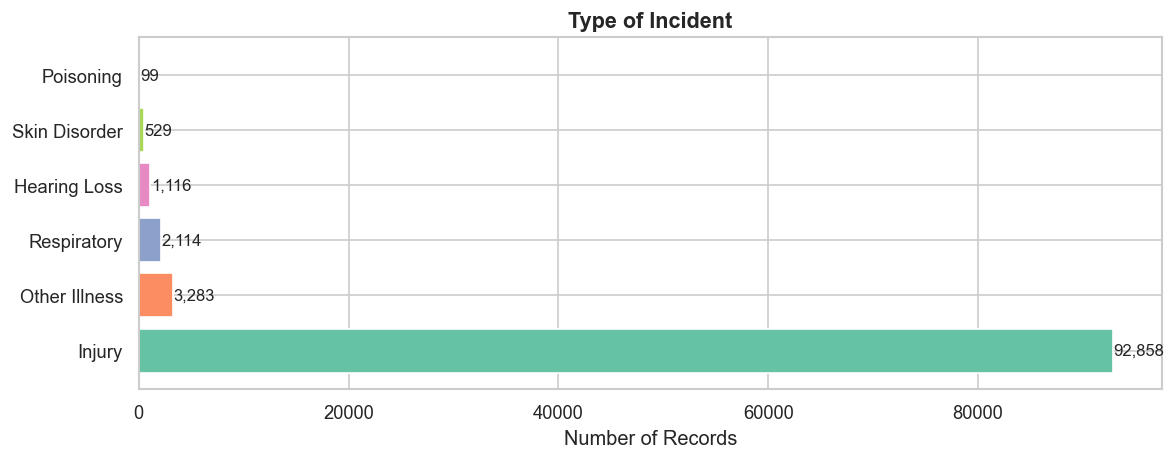

In [13]:
#Type of Incident
#Describes what *kind* of injury or illness occurred (e.g., physical injury vs. respiratory condition). This column gives context to the narrative text.

#Type of incident distribution
type_labels = {1:'Injury', 2:'Skin Disorder', 3:'Respiratory',
               4:'Poisoning', 5:'Hearing Loss', 6:'Other Illness'}
df['incident_type_label'] = df['type_of_incident'].map(type_labels)

type_counts = df['incident_type_label'].value_counts()
fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(type_counts.index, type_counts.values,
        color=sns.color_palette('Set2', len(type_counts)))
ax.set_title('Type of Incident', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Records')
for i, (val, name) in enumerate(zip(type_counts.values, type_counts.index)):
    ax.text(val + 50, i, f'{val:,}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

In [14]:
print("Physical Injury dominates at ~93% of all incidents.")
print("Illness types (Respiratory, Other Illness, Skin Disorder) make up the remaining percent.")
print("Despite being rare, Respiratory cases are disproportionately High Priority.")

Physical Injury dominates at ~93% of all incidents.
Illness types (Respiratory, Other Illness, Skin Disorder) make up the remaining percent.
Despite being rare, Respiratory cases are disproportionately High Priority.


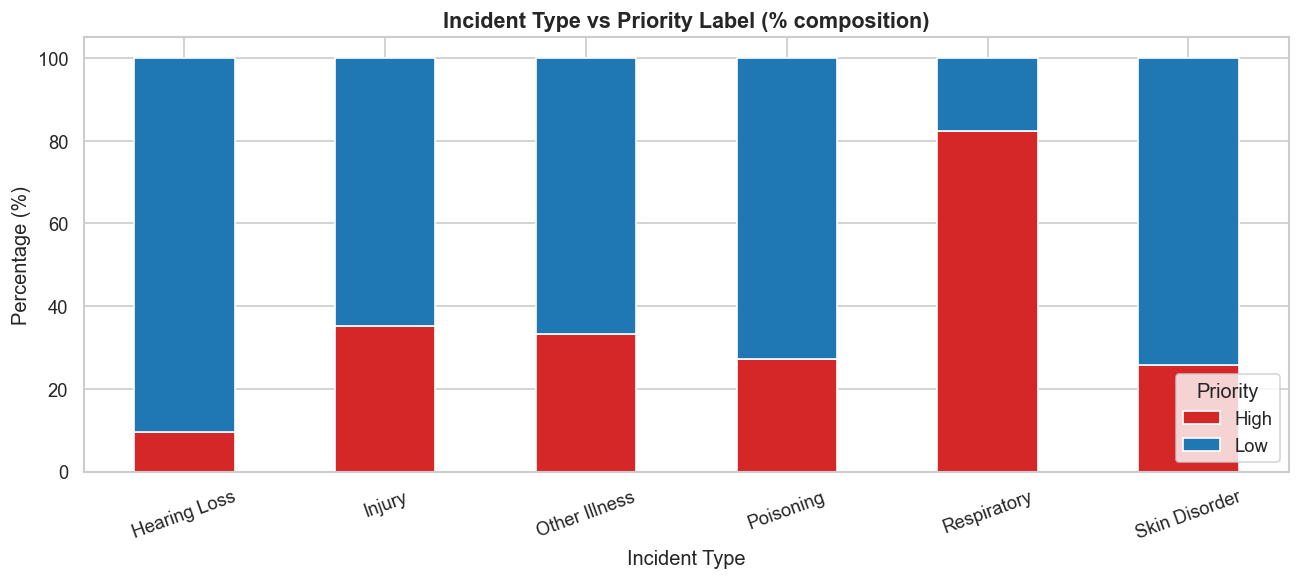

In [15]:
#Priority label vs Incident type (stacked)
cross = pd.crosstab(df['incident_type_label'], df['priority_label'], normalize='index') * 100
cross.plot(kind='bar', stacked=True, figsize=(11, 5),
           color=['#d62728', '#1f77b4'], edgecolor='white')
plt.title('Incident Type vs Priority Label (% composition)', fontsize=13, fontweight='bold')
plt.ylabel('Percentage (%)')
plt.xlabel('Incident Type')
plt.xticks(rotation=20)
plt.legend(title='Priority', loc='lower right')

plt.tight_layout()
plt.show()

In [16]:
print("Respiratory conditions skew heavily toward High Priority (~82%).")
print("Injuries are the most common type but skew toward Low Priority (~65%).")
print("Hearing Loss and Skin Disorder are almost entirely Low Priority.")
print("Poisoning and Other Illness also skew Low Priority.")

Respiratory conditions skew heavily toward High Priority (~82%).
Injuries are the most common type but skew toward Low Priority (~65%).
Hearing Loss and Skin Disorder are almost entirely Low Priority.
Poisoning and Other Illness also skew Low Priority.


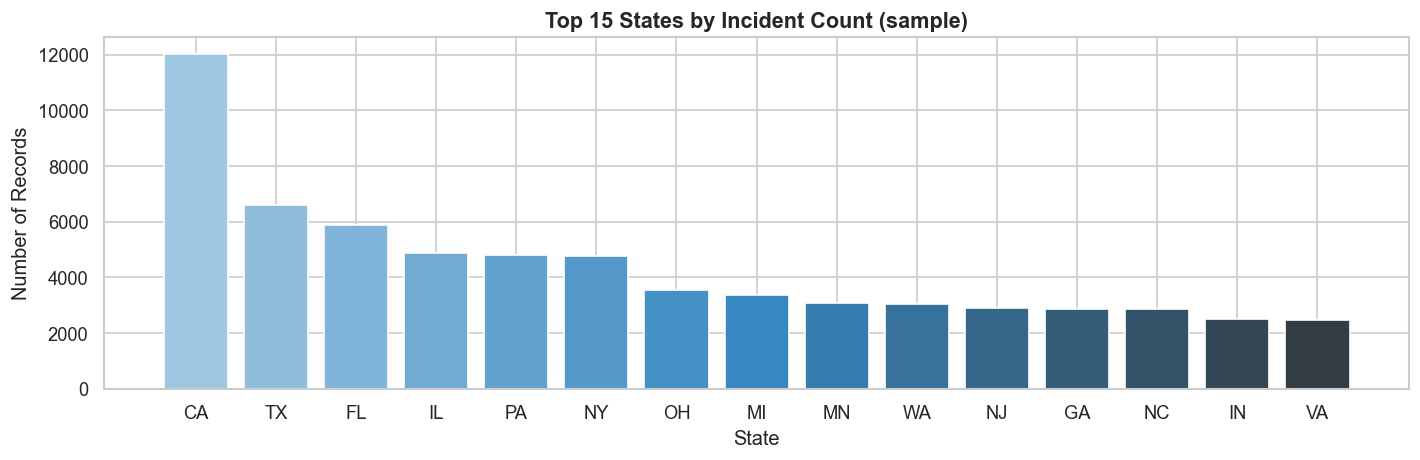

In [17]:
#Top states by incident count
#Understanding geographic distribution helps contextualise the dataset, even though state is not used as a model feature (too many unique values, not directly relevant to text-based classification)

state_counts = df['state'].value_counts().head(15)
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(state_counts.index, state_counts.values,
       color=sns.color_palette('Blues_d', len(state_counts)), edgecolor='white')
ax.set_title('Top 15 States by Incident Count (sample)', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Records')
ax.set_xlabel('State')

plt.tight_layout()
plt.show()

In [18]:
print("California, Texas and Florida report the most incidents, reflecting their large workforces.")
print("State is not used as a model feature — it has too many unique values and does")
print("not directly describe what happened or how serious the incident was.")

California, Texas and Florida report the most incidents, reflecting their large workforces.
State is not used as a model feature — it has too many unique values and does
not directly describe what happened or how serious the incident was.


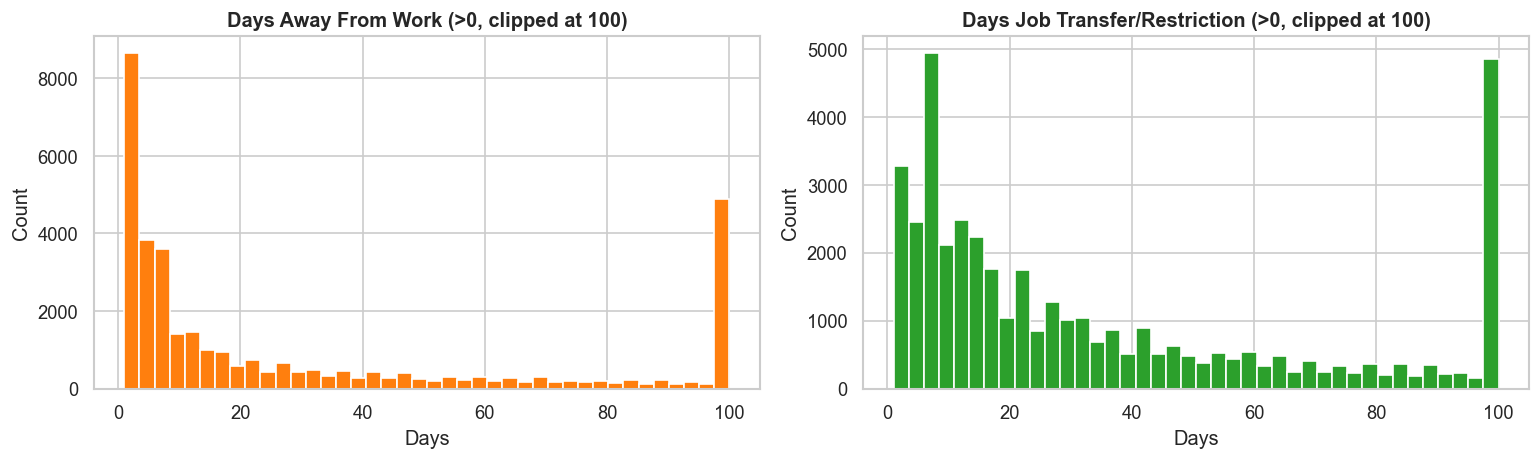

DAFW  — median: 0, mean: 12.2, max: 680
DJTR  — median: 0,  mean: 14.9, max: 408


In [19]:
#Severity Indicators — Days Away From Work & Transfer Days
#These numeric columns quantify severity:
#dafw_num_away: days the employee was absent (0 for non-DAFW cases)
#djtr_num_tr: days on restricted/transferred duty

#They are included as additional numeric features alongside the NLP text features.

#DAFW and DJTR distributions 
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

#Filter to cases with at least 1 day (0s dominate and obscure the distribution)
dafw = df[df['dafw_num_away'] > 0]['dafw_num_away'].clip(upper=100)
djtr = df[df['djtr_num_tr'] > 0]['djtr_num_tr'].clip(upper=100)

axes[0].hist(dafw, bins=40, color='#ff7f0e', edgecolor='white')
axes[0].set_title('Days Away From Work (>0, clipped at 100)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Days'); axes[0].set_ylabel('Count')

axes[1].hist(djtr, bins=40, color='#2ca02c', edgecolor='white')
axes[1].set_title('Days Job Transfer/Restriction (>0, clipped at 100)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Days'); axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f"DAFW  — median: {df['dafw_num_away'].median():.0f}, mean: {df['dafw_num_away'].mean():.1f}, max: {df['dafw_num_away'].max():.0f}")
print(f"DJTR  — median: {df['djtr_num_tr'].median():.0f},  mean: {df['djtr_num_tr'].mean():.1f}, max: {df['djtr_num_tr'].max():.0f}")


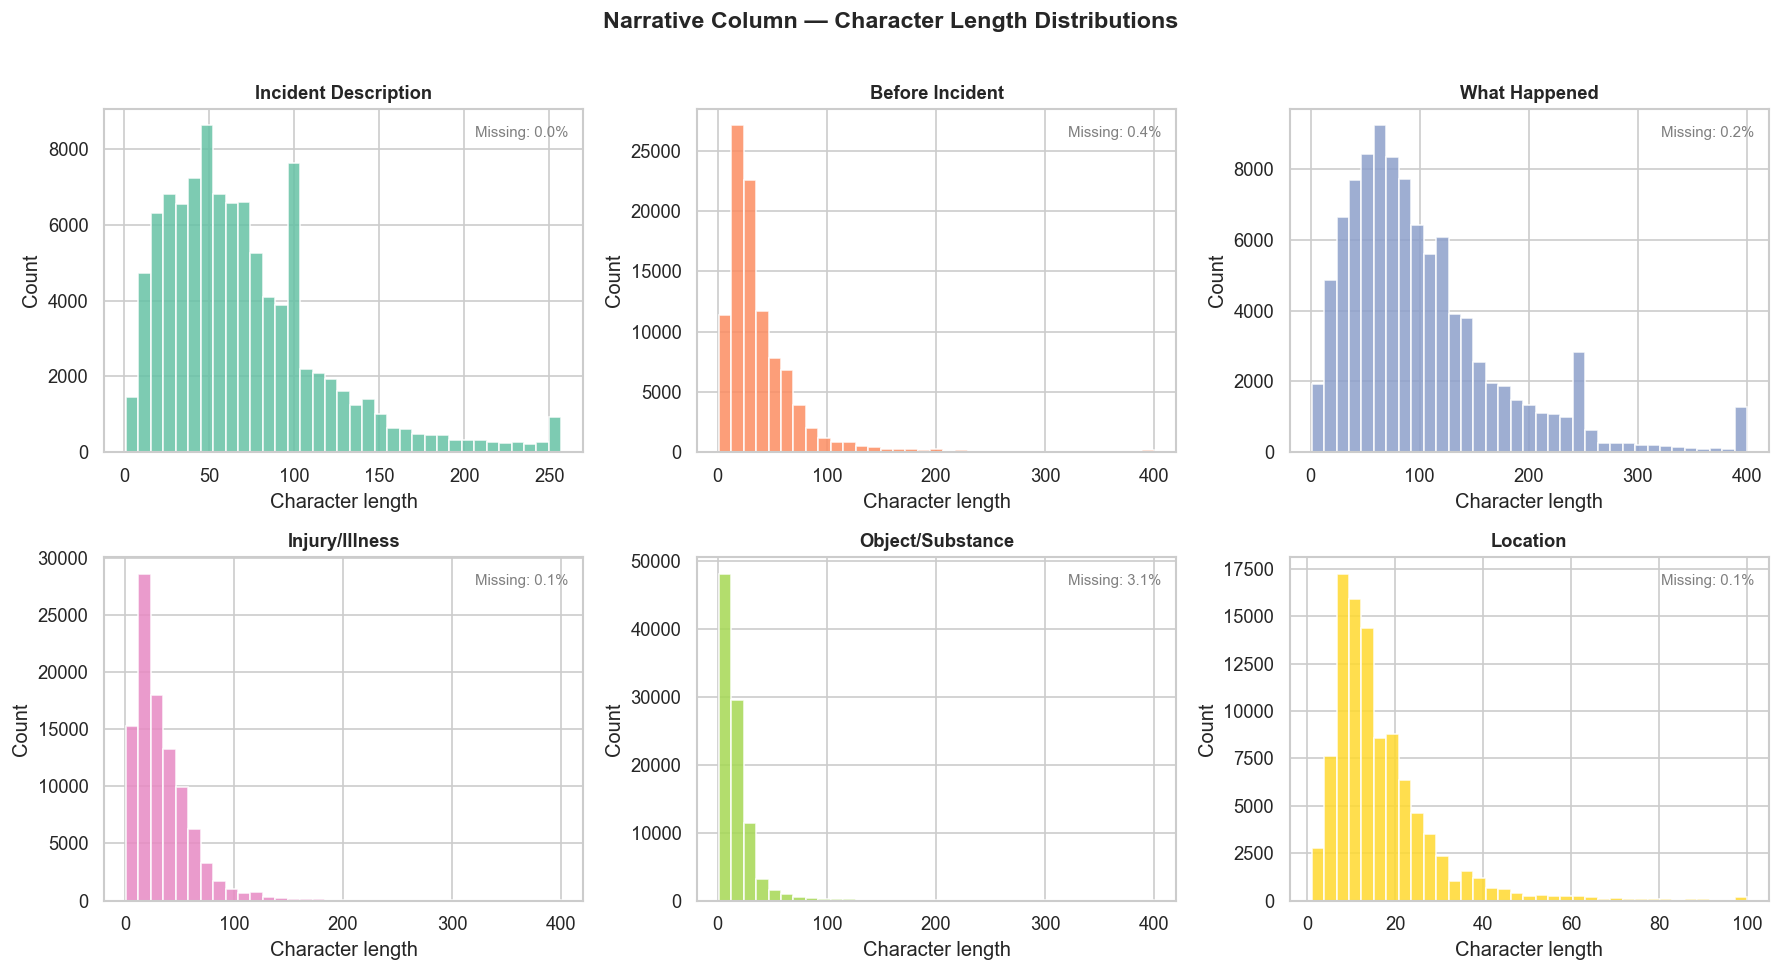

In [20]:
#Narrative Text Columns — Length Analysis
#The six narrative columns are the core NLP inputs. Understanding their length distribution tells us:
#How much information is typically available
#Whether some fields are often empty or very short (which affects how we combine them)

#Narrative text length distributions
nar_cols = ['New_incident_description', 'New_nar_before_incident',
            'New_nar_what_happened', 'New_nar_injury_illness',
            'New_nar_object_substance', 'New_incident_location']

nar_labels = ['Incident Description', 'Before Incident',
              'What Happened', 'Injury/Illness',
              'Object/Substance', 'Location']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
palette = sns.color_palette('Set2', 6)

for ax, col, label, color in zip(axes, nar_cols, nar_labels, palette):
    lengths = df[col].dropna().str.len().clip(upper=400)
    ax.hist(lengths, bins=35, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlabel('Character length'); ax.set_ylabel('Count')
    missing_pct = df[col].isnull().mean() * 100
    ax.text(0.97, 0.95, f'Missing: {missing_pct:.1f}%',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=9, color='red' if missing_pct > 5 else 'grey')

plt.suptitle('Narrative Column — Character Length Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


In [21]:
print("'What Happened' and 'Before Incident' are the longest fields (mean ~90 and ~50 chars).")
print("'Location' and 'Object/Substance' are the shortest — often just 1-3 words.")
print("All six fields are concatenated into a single combined_text for TF-IDF input.")
print("Shorter fields still contribute useful keywords even if they are brief.")

'What Happened' and 'Before Incident' are the longest fields (mean ~90 and ~50 chars).
'Location' and 'Object/Substance' are the shortest — often just 1-3 words.
All six fields are concatenated into a single combined_text for TF-IDF input.
Shorter fields still contribute useful keywords even if they are brief.


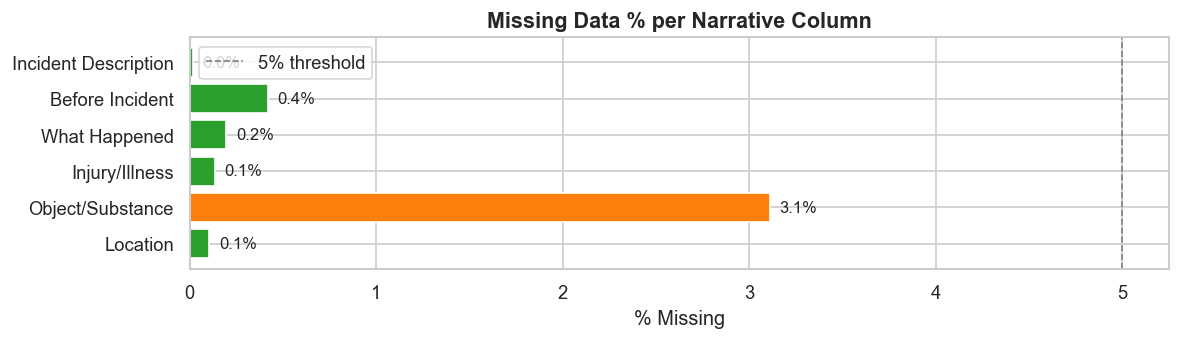

Object/Substance has the highest missing rate.
All other narrative fields are under 0.5% missing.
We fill missing values with an empty string before concatenation, so no rows are dropped due to a single missing narrative field.


In [22]:
#Missing data for narrative columns

missing_df = df[nar_cols].isnull().astype(int)
missing_pct = missing_df.mean() * 100

fig, ax = plt.subplots(figsize=(10, 3))
bars = ax.barh(nar_labels[::-1], missing_pct[nar_cols].values[::-1],
               color=['#d62728' if v > 5 else '#ff7f0e' if v > 1 else '#2ca02c'
                      for v in missing_pct[nar_cols].values[::-1]])
ax.set_title('Missing Data % per Narrative Column', fontsize=13, fontweight='bold')
ax.set_xlabel('% Missing')
ax.axvline(5, color='grey', linestyle='--', linewidth=1, label='5% threshold')
ax.legend()
for bar, val in zip(bars, missing_pct[nar_cols].values[::-1]):
    ax.text(val + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print("Object/Substance has the highest missing rate.")
print("All other narrative fields are under 0.5% missing.")
print("We fill missing values with an empty string before concatenation, so no rows are dropped due to a single missing narrative field.")


In [23]:
#Determine domain stopwords from the data
#Step 1: Build a raw corpus of ALL narrative text (no stopwords yet)
all_corpus = df[nar_cols].fillna('').apply(
    lambda row: ' '.join(row.values.astype(str)), axis=1)

#Step 2: Count word frequencies after removing standard English stopwords
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(stop_words='english', max_features=100)
cv.fit(all_corpus)
word_counts = cv.transform(all_corpus).sum(axis=0)
freq_df = pd.DataFrame({
    'word': cv.get_feature_names_out(),
    'count': np.asarray(word_counts).flatten()
}).sort_values('count', ascending=False)

print("Top 50 most frequent words after standard stopwords:")
print(freq_df.head(50).to_string(index=False))

Top 50 most frequent words after standard stopwords:
      word  count
      left  70326
     right  69924
  employee  41864
    strain  38787
      pain  37140
        ee  33676
   patient  32192
    finger  30271
      hand  29632
  shoulder  26125
      knee  23742
      fell  21705
      felt  21455
    needle  21238
     lower  20724
       box  20503
   lifting  20049
     floor  18906
    sprain  18854
  redacted  18742
      foot  16760
    injury  16429
 contusion  16079
   package  15703
    pallet  15291
      room  15224
     wrist  15140
   walking  15082
     ankle  15010
 associate  14507
      head  14346
       cut  13866
       arm  13668
      fall  13446
laceration  13076
      cart  13050
    struck  12943
   slipped  12939
      area  12839
      door  12810
       hit  12597
  strained  11506
   pulling  10938
   causing  10833
     thumb  10671
   working  10043
      body   9988
       leg   9377
        aa   9274
    moving   9007


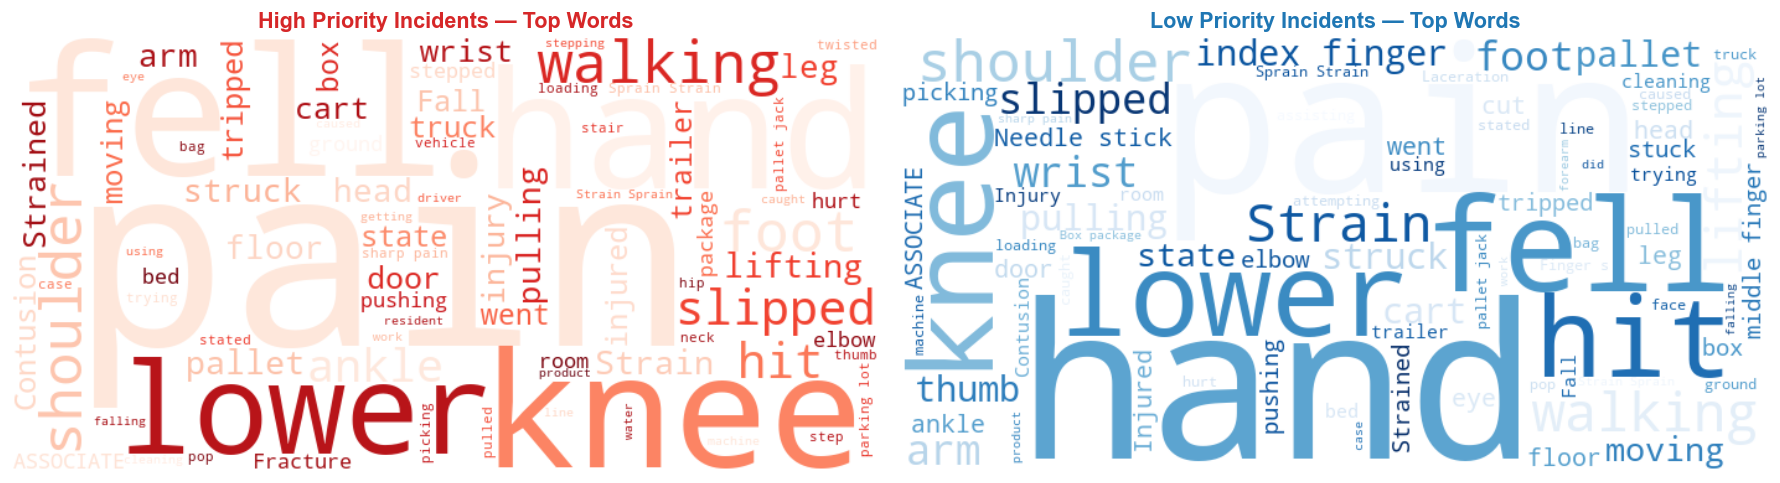

In [24]:
#Word Clouds — High Priority vs Low Priority Narratives
#Word clouds visualise the most frequent meaningful words in the combined narrative text, split by priority class. Words that appear more in High Priority narratives should capture the model's attention.

#Word clouds by priority
#Domain stopwords determined from top-50 frequency analysis above.
#Words that appear universally across all incident types and carry no discriminative power between High and Low priority.
domain_stopwords = set(ENGLISH_STOP_WORDS) | {
    'left',       # body side indicator — present in virtually every record
    'right',      # body side indicator — present in virtually every record
    'employee',   # every record concerns an employee
    'ee',         # OSHA abbreviation for employee — same as above
    'patient',    # used universally in healthcare incidents
    'redacted',   # OSHA PII masking token — not meaningful text
    'felt',       # filler phrase ("employee felt...") — in almost every record
    'area',       # generic location word — no severity signal
    'working',    # every record is work-related
    'causing',    # generic linking verb — no severity signal
    'body',       # too generic to be informative
    'aa',         # noise abbreviation with no clear meaning
}

def make_corpus(priority):
    subset = df[df['priority_label'] == priority][nar_cols]
    return ' '.join(
        subset.fillna('').apply(lambda row: ' '.join(row.values.astype(str)), axis=1)
    )

high_text = make_corpus('High')
low_text  = make_corpus('Low')

wc_high = WordCloud(width=700, height=350, background_color='white',
                    stopwords=domain_stopwords, colormap='Reds',
                    random_state=RANDOM_SEED, max_words=80).generate(high_text)
wc_low  = WordCloud(width=700, height=350, background_color='white',
                    stopwords=domain_stopwords, colormap='Blues',
                    random_state=RANDOM_SEED, max_words=80).generate(low_text)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].imshow(wc_high, interpolation='bilinear')
axes[0].set_title('High Priority Incidents — Top Words', fontsize=13, fontweight='bold', color='#d62728')
axes[0].axis('off')
axes[1].imshow(wc_low, interpolation='bilinear')
axes[1].set_title('Low Priority Incidents — Top Words', fontsize=13, fontweight='bold', color='#1f77b4')
axes[1].axis('off')

plt.tight_layout()
plt.show()


In [25]:
print("High priority narratives frequently mention: fell, hit, knee, hand, shoulder, foot")
print("Low priority narratives share body-part terms but add: needle, finger, box, wrist")
print("The overlap in vocabulary is why we need TF-IDF weighting — not just raw word counts.")

High priority narratives frequently mention: fell, hit, knee, hand, shoulder, foot
Low priority narratives share body-part terms but add: needle, finger, box, wrist
The overlap in vocabulary is why we need TF-IDF weighting — not just raw word counts.


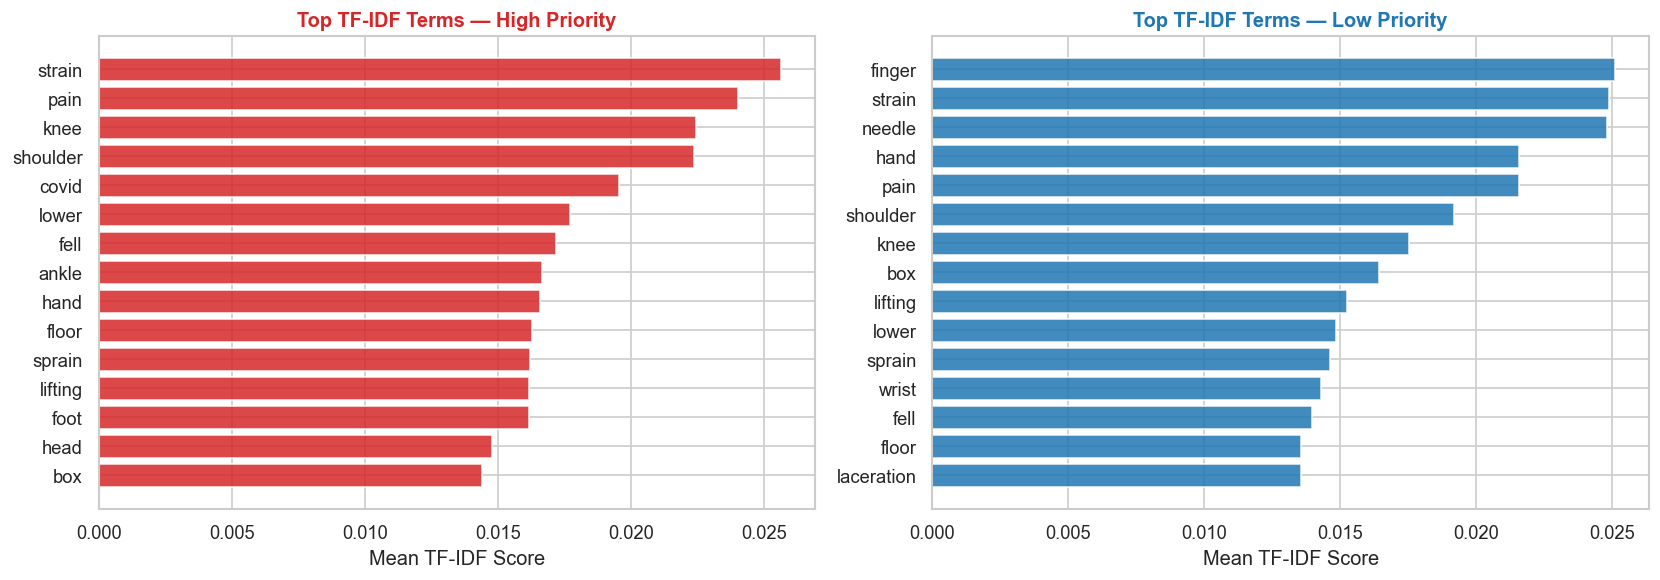

In [26]:
#Top TF-IDF Terms per Priority Class
#TF-IDF scores the importance of each word relative to the class. The chart below shows the 15 highest-weighted terms for High and Low priority — these are the words the model will treat as most informative.

#Top TF-IDF terms per class
from sklearn.feature_extraction.text import TfidfVectorizer

def get_top_tfidf(corpus_list, n=15):
    tfidf = TfidfVectorizer(max_features=5000, stop_words=list(domain_stopwords), ngram_range=(1, 2))
    X = tfidf.fit_transform(corpus_list)
    scores = np.asarray(X.mean(axis=0)).flatten()
    terms = np.array(tfidf.get_feature_names_out())
    top_idx = scores.argsort()[::-1][:n]
    return terms[top_idx], scores[top_idx]

high_corpus = df[df['priority_label']=='High'][nar_cols].fillna('').apply(
    lambda r: ' '.join(r.values.astype(str)), axis=1).tolist()
low_corpus  = df[df['priority_label']=='Low'][nar_cols].fillna('').apply(
    lambda r: ' '.join(r.values.astype(str)), axis=1).tolist()

h_terms, h_scores = get_top_tfidf(high_corpus)
l_terms, l_scores = get_top_tfidf(low_corpus)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(h_terms[::-1], h_scores[::-1], color='#d62728', alpha=0.85)
axes[0].set_title('Top TF-IDF Terms — High Priority', fontsize=12, fontweight='bold', color='#d62728')
axes[0].set_xlabel('Mean TF-IDF Score')

axes[1].barh(l_terms[::-1], l_scores[::-1], color='#1f77b4', alpha=0.85)
axes[1].set_title('Top TF-IDF Terms — Low Priority', fontsize=12, fontweight='bold', color='#1f77b4')
axes[1].set_xlabel('Mean TF-IDF Score')

plt.tight_layout()
plt.show()


In [27]:
print("Both classes share body-part terms (strain, pain, knee, shoulder) —")
print("the model distinguishes them through subtle vocabulary and phrase-level differences.")
print("High Priority uniquely features: covid, floor, fell, ankle (serious falls and illness).")
print("Low Priority uniquely features: finger, needle, box, wrist (minor cuts and sprains).")

Both classes share body-part terms (strain, pain, knee, shoulder) —
the model distinguishes them through subtle vocabulary and phrase-level differences.
High Priority uniquely features: covid, floor, fell, ankle (serious falls and illness).
Low Priority uniquely features: finger, needle, box, wrist (minor cuts and sprains).


In [28]:
#Columns that are dropped — and why
#Not every column in the dataset is useful for the classification task. Below we document each dropped column and the reason for exclusion.

#Dropped columns documentation
dropped = {
    'ID'                  : 'Unique record identifier — no predictive signal',
    'establishment_ID'    : 'Unique establishment ID — no predictive signal',
    'establishment_name'  : 'Free-text name — not useful for incident severity',
    'ein'                 : 'Tax ID — administrative, no predictive signal',
    'company_name'        : 'Company name — not related to incident severity',
    'street_address'      : 'Street address — too specific, no predictive signal',
    'zip_code'            : 'Postal code — too granular, better represented by state',
    'naics_code'          : 'Numeric code — replaced by industry_description text',
    'naics_year'          : 'Version year of NAICS codes — administrative metadata',
    'case_number'         : 'Employer case reference — no predictive signal',
    'date_of_incident'    : 'Date only — not used (time patterns not in scope)',
    'time_started_work'   : 'Shift start time — weak signal for classification',
    'time_of_incident'    : 'Incident time — weak signal for classification',
    'time_unknown'        : 'Flag for unknown time — not predictive of severity',
    'date_of_death'       : 'Death date — leakage risk (only present for deaths)',
    'created_timestamp'   : 'Record submission timestamp — administrative',
    'year_of_filing'      : 'Filing year — administrative, not severity-related',
    'SOC_code'            : 'Occupation code — represented by SOC_description text',
    'SOC_probability'     : 'Model confidence for SOC assignment — meta-data',
    'SOC_reviewed'        : 'Review flag — administrative, not severity-related',
}

print(f"{'Column':<25} {'Reason'}")
print("-" * 85)
for col, reason in dropped.items():
    print(f"{col:<25} {reason}")
print(f"\nTotal dropped: {len(dropped)} columns")

kept = ['incident_outcome (→ target)', 'type_of_incident', 'dafw_num_away',
        'djtr_num_tr', 'size', 'establishment_type', 'annual_average_employees',
        'industry_description', 'SOC_description', 'job_description',
        'New_incident_description', 'New_nar_before_incident', 'New_nar_what_happened',
        'New_nar_injury_illness', 'New_nar_object_substance', 'New_incident_location']

print(f"\nColumns kept for modelling ({len(kept)}):")
for c in kept:
    print(f" {c}")

Column                    Reason
-------------------------------------------------------------------------------------
ID                        Unique record identifier — no predictive signal
establishment_ID          Unique establishment ID — no predictive signal
establishment_name        Free-text name — not useful for incident severity
ein                       Tax ID — administrative, no predictive signal
company_name              Company name — not related to incident severity
street_address            Street address — too specific, no predictive signal
zip_code                  Postal code — too granular, better represented by state
naics_code                Numeric code — replaced by industry_description text
naics_year                Version year of NAICS codes — administrative metadata
case_number               Employer case reference — no predictive signal
date_of_incident          Date only — not used (time patterns not in scope)
time_started_work         Shift start time —

In [29]:
#Preprocessing

#Binary Target Variable has been created earlier
#High = 1  (Death or Days Away From Work — requires urgent action)
#Low  = 0  (Job Transfer / Other Recordable — less time-critical)

In [30]:
#Dropping unnecessary columns

#Select columns to keep
keep_cols = [
    # Target
    'priority_label',
    # Narrative text (NLP features)
    'New_incident_description', 'New_nar_before_incident', 'New_nar_what_happened',
    'New_nar_injury_illness', 'New_nar_object_substance', 'New_incident_location',
    # Structured features
    'type_of_incident', 'dafw_num_away', 'djtr_num_tr',
    'size', 'establishment_type', 'annual_average_employees',
    'industry_description', 'SOC_description', 'job_description',
]

df_clean = df[keep_cols].copy()

# Map priority to numeric (1=High, 0=Low) for modelling
df_clean['priority_label'] = df_clean['priority_label'].map({'High': 1, 'Low': 0})


print(f"Shape after column selection: {df_clean.shape}")

print(df_clean['priority_label'].value_counts())

Shape after column selection: (99999, 16)
priority_label
0    64244
1    35755
Name: count, dtype: int64


In [31]:
#Handling Missing Values
#Fill missing values
nar_cols_use = ['New_incident_description', 'New_nar_before_incident', 'New_nar_what_happened',
                'New_nar_injury_illness', 'New_nar_object_substance', 'New_incident_location',
                'industry_description', 'SOC_description', 'job_description']

num_cols = ['dafw_num_away', 'djtr_num_tr', 'annual_average_employees',
            'size', 'establishment_type', 'type_of_incident']

#Text fields: empty string (absent narrative ≠ informative word)
for col in nar_cols_use:
    df_clean[col] = df_clean[col].fillna('')

#Numeric fields: 0 (a missing day count means 0 days absent)
for col in num_cols:
    df_clean[col] = df_clean[col].fillna(0)

print("Missing values after filling:")
print(df_clean.isnull().sum())

Missing values after filling:
priority_label              0
New_incident_description    0
New_nar_before_incident     0
New_nar_what_happened       0
New_nar_injury_illness      0
New_nar_object_substance    0
New_incident_location       0
type_of_incident            0
dafw_num_away               0
djtr_num_tr                 0
size                        0
establishment_type          0
annual_average_employees    0
industry_description        0
SOC_description             0
job_description             0
dtype: int64


In [32]:
#Clean Narrative Text — Each Field Individually
#We clean each of the 6 narrative fields separately.
#ColumnTransformer in the modelling step applies a separate TF-IDF per field.
#This way location words do not compete with injury description words.

#Normalisation applied to each field:
# Lowercase — "Fracture" and "fracture" treated identically
# Remove punctuation — keeps only letters and spaces
# Collapse whitespace — removes extra spaces

def clean_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

nar_fields = ['New_incident_description', 'New_nar_before_incident',
              'New_nar_what_happened', 'New_nar_injury_illness',
              'New_nar_object_substance', 'New_incident_location']

#Clean each field individually
for col in nar_fields:
    df_clean[col] = df_clean[col].apply(clean_text)

#Drop rows where ALL narrative fields are empty — completely uninformative
before = len(df_clean)
all_empty = df_clean[nar_fields].apply(lambda row: all(v.strip() == '' for v in row), axis=1)
df_clean = df_clean[~all_empty].reset_index(drop=True)
print(f"Dropped {before - len(df_clean)} rows with all narrative fields empty")
print(f"\nSample cleaned 'New_nar_what_happened':")
print(df_clean['New_nar_what_happened'].iloc[0])
print(f"\nSample cleaned 'New_incident_location':")
print(df_clean['New_incident_location'].iloc[0])

Dropped 0 rows with all narrative fields empty

Sample cleaned 'New_nar_what_happened':
collision with another vehicle

Sample cleaned 'New_incident_location':
road hwy street state route sb


In [33]:
#Numeric Features
#dafw_num_away and djtr_num_tr carry real severity information but have extreme outliers. They are cut (clipped) at the 99th percentile to prevent any single extreme value from dominating the model.
#A simple total_severity_days feature that sums both fields is created.

p99_dafw = df_clean['dafw_num_away'].quantile(0.99)
p99_djtr = df_clean['djtr_num_tr'].quantile(0.99)

df_clean['dafw_clipped'] = df_clean['dafw_num_away'].clip(upper=p99_dafw)
df_clean['djtr_clipped'] = df_clean['djtr_num_tr'].clip(upper=p99_djtr)
df_clean['total_severity_days'] = df_clean['dafw_clipped'] + df_clean['djtr_clipped']

print(f"DAFW  99th percentile clip point : {p99_dafw:.0f} days")
print(f"DJTR  99th percentile clip point : {p99_djtr:.0f} days")
print(f"\nnew feature 'total_severity_days' stats:")
print(df_clean['total_severity_days'].describe().round(2))

DAFW  99th percentile clip point : 180 days
DJTR  99th percentile clip point : 180 days

new feature 'total_severity_days' stats:
count    99999.00
mean        26.86
std        377.65
min     -99999.00
25%          0.00
50%          7.00
75%         34.00
max        360.00
Name: total_severity_days, dtype: float64


Before balancing — High: 35,755  Low: 64,244
After  balancing — High: 35,755  Low: 35,755
Total balanced dataset size: 71,510


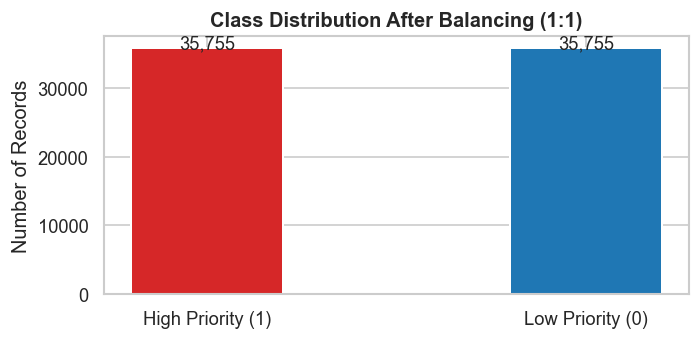

In [34]:
#Handling class imbalance using Downsampling

#Downsample majority class to balance 1:
high_df = df_clean[df_clean['priority_label'] == 1]
low_df  = df_clean[df_clean['priority_label'] == 0]

print(f"Before balancing — High: {len(high_df):,}  Low: {len(low_df):,}")

minority_size = min(len(high_df), len(low_df))

high_balanced = resample(high_df, replace=False, n_samples=minority_size,
                         random_state=RANDOM_SEED)
low_balanced  = resample(low_df,  replace=False, n_samples=minority_size,
                         random_state=RANDOM_SEED)

df_balanced = pd.concat([high_balanced, low_balanced]).sample(
    frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

print(f"After  balancing — High: {df_balanced['priority_label'].sum():,}  "
      f"Low: {(df_balanced['priority_label']==0).sum():,}")
print(f"Total balanced dataset size: {len(df_balanced):,}")

#Visualise after balancing
fig, ax = plt.subplots(figsize=(6, 3))
counts_b = df_balanced['priority_label'].value_counts()
ax.bar(['High Priority (1)', 'Low Priority (0)'],
       [counts_b[1], counts_b[0]],
       color=['#d62728', '#1f77b4'], edgecolor='white', linewidth=1.2, width=0.4)
ax.set_title('Class Distribution After Balancing (1:1)', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Records')
for bar, val in zip(ax.patches, [counts_b[1], counts_b[0]]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{val:,}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()


In [51]:
#Train / Test split
#80% Training — used to fit and cross-validate the model
#20% Test     — held out completely until final evaluation (unseen data)
#stratify=y ensures 1:1 class balance is preserved in both halves
#RANDOM_SEED guarantees the exact same rows go to the same split every run

#Input features: 6 individual text fields + 3 numeric severity features
text_cols = [
    'New_incident_description', 'New_nar_before_incident', 'New_nar_what_happened',
    'New_nar_injury_illness', 'New_nar_object_substance', 'New_incident_location'
]
num_cols_model = []
feature_cols = text_cols

X = df_balanced[feature_cols]
y = df_balanced['priority_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_SEED
)

print(f"Input features  : {len(text_cols)} text fields + {len(num_cols_model)} numeric fields")
print(f"Output variable : priority_label (1=High Priority, 0=Low Priority)")
print(f"\nTraining set   : {len(X_train):,} rows  ({y_train.sum():,} High | {(y_train==0).sum():,} Low)")
print(f"Test set       : {len(X_test):,} rows   ({y_test.sum():,} High | {(y_test==0).sum():,} Low)")

Input features  : 6 text fields + 0 numeric fields
Output variable : priority_label (1=High Priority, 0=Low Priority)

Training set   : 57,208 rows  (28,604 High | 28,604 Low)
Test set       : 14,302 rows   (7,151 High | 7,151 Low)


In [52]:
#The train dataset and test dataset are saved in dataframes

train_df = pd.concat([X_train, y_train], axis=1).reset_index(drop=True)
test_df  = pd.concat([X_test,  y_test],  axis=1).reset_index(drop=True)

print(f"train_df : {train_df.shape[0]:,} rows")
print(f"test_df  : {test_df.shape[0]:,} rows")
print(f"\nClass balance in train_df:")
print(train_df['priority_label'].value_counts().rename({1:'High', 0:'Low'}))
print(f"\nClass balance in test_df:")
print(test_df['priority_label'].value_counts().rename({1:'High', 0:'Low'}))

train_df : 57,208 rows
test_df  : 14,302 rows

Class balance in train_df:
priority_label
Low     28604
High    28604
Name: count, dtype: int64

Class balance in test_df:
priority_label
High    7151
Low     7151
Name: count, dtype: int64


In [53]:
#MODELLING
#Two models trained and compared:
#  1. Logistic Regression — baseline, fast, interpretable
#  2. Random Forest       — captures non-linear relationships
#
#Both use a ColumnTransformer + Pipeline:
#  - Separate TF-IDF vectoriser for each of the 6 narrative text fields
#  - StandardScaler for the 3 numeric features
#  - All features combined into one matrix before the classifier
#
#This approach is better than combining all text into one field because:
#  - Location words do not dilute injury description words
#  - Each field gets its own feature budget (more features to important fields)
#  - Numeric severity features are properly scaled alongside text features

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay,
                             accuracy_score, f1_score, recall_score, precision_score)

print("All modelling libraries loaded.")

All modelling libraries loaded.


In [54]:
#ColumnTransformer — separate TF-IDF per text field + scaled numerics
#
#Feature budgets assigned by field importance:
#  New_nar_what_happened    3000 — most descriptive, highest budget
#  New_incident_description 3000 — second most descriptive
#  New_nar_injury_illness   2000 — specific injury/illness vocabulary
#  New_nar_before_incident  2000 — context before incident
#  New_nar_object_substance 1000 — shorter field, fewer features needed
#  New_incident_location     500 — usually just 1-3 words
#
#Total text features: ~11,500
#Numeric features: 3 (scaled)

preprocessor = ColumnTransformer(transformers=[
    ('tfidf_desc',     TfidfVectorizer(max_features=3000, ngram_range=(1,2),
                       stop_words=list(domain_stopwords), sublinear_tf=True),
                       'New_incident_description'),
    ('tfidf_before',   TfidfVectorizer(max_features=2000, ngram_range=(1,2),
                       stop_words=list(domain_stopwords), sublinear_tf=True),
                       'New_nar_before_incident'),
    ('tfidf_happened', TfidfVectorizer(max_features=3000, ngram_range=(1,2),
                       stop_words=list(domain_stopwords), sublinear_tf=True),
                       'New_nar_what_happened'),
    ('tfidf_illness',  TfidfVectorizer(max_features=2000, ngram_range=(1,2),
                       stop_words=list(domain_stopwords), sublinear_tf=True),
                       'New_nar_injury_illness'),
    ('tfidf_object',   TfidfVectorizer(max_features=1000, ngram_range=(1,2),
                       stop_words=list(domain_stopwords), sublinear_tf=True),
                       'New_nar_object_substance'),
    ('tfidf_location', TfidfVectorizer(max_features=500, ngram_range=(1,2),
                       stop_words=list(domain_stopwords), sublinear_tf=True),
                       'New_incident_location'),
])

#Model 1 — Logistic Regression
#class_weight='balanced' handles any residual imbalance
#C=1.0 is default regularisation — controls overfitting
#max_iter=1000 ensures convergence on large feature spaces
pipeline_lr = Pipeline([
    ('features', preprocessor),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000,
                               random_state=RANDOM_SEED, C=1.0))
])

#Model 2 — Random Forest
#n_estimators=200 — 200 decision trees voted together
#max_depth=20 — prevents overfitting
#class_weight='balanced' — handles residual imbalance
pipeline_rf = Pipeline([
    ('features', preprocessor),
    ('clf', RandomForestClassifier(n_estimators=200, max_depth=20,
                                   class_weight='balanced',
                                   random_state=RANDOM_SEED, n_jobs=-1))
])

print("Model 1 — Logistic Regression pipeline ready")
print("Model 2 — Random Forest pipeline ready")
print(f"\nInput  : {len(text_cols)} text fields (separate TF-IDF each) + {len(num_cols_model)} numeric features")
print(f"Output : priority_label (1=High Priority, 0=Low Priority)")

Model 1 — Logistic Regression pipeline ready
Model 2 — Random Forest pipeline ready

Input  : 6 text fields (separate TF-IDF each) + 0 numeric features
Output : priority_label (1=High Priority, 0=Low Priority)


In [55]:
#Cross-Validation on Training Set
#5-fold Stratified Cross-Validation on training data only.
#Stratified ensures each fold has the same 1:1 class ratio.
#Test set is NOT touched at this stage.

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
scoring = ['accuracy', 'f1_weighted', 'recall_macro', 'precision_macro', 'roc_auc']

print("Running 5-fold cross-validation on Logistic Regression...")
cv_lr = cross_validate(pipeline_lr, X_train, y_train,
                       cv=cv, scoring=scoring, n_jobs=-1)

print("Running 5-fold cross-validation on Random Forest...")
cv_rf = cross_validate(pipeline_rf, X_train, y_train,
                       cv=cv, scoring=scoring, n_jobs=-1)

print("\nCross-validation complete.")

Running 5-fold cross-validation on Logistic Regression...
Running 5-fold cross-validation on Random Forest...

Cross-validation complete.


In [56]:
#Cross-Validation Results Summary
cv_results = pd.DataFrame({
    'Metric': ['Accuracy', 'F1 (weighted)', 'Recall (macro)', 'Precision (macro)', 'AUC-ROC'],
    'LR Mean': [cv_lr['test_accuracy'].mean(), cv_lr['test_f1_weighted'].mean(),
                cv_lr['test_recall_macro'].mean(), cv_lr['test_precision_macro'].mean(),
                cv_lr['test_roc_auc'].mean()],
    'LR Std':  [cv_lr['test_accuracy'].std(), cv_lr['test_f1_weighted'].std(),
                cv_lr['test_recall_macro'].std(), cv_lr['test_precision_macro'].std(),
                cv_lr['test_roc_auc'].std()],
    'RF Mean': [cv_rf['test_accuracy'].mean(), cv_rf['test_f1_weighted'].mean(),
                cv_rf['test_recall_macro'].mean(), cv_rf['test_precision_macro'].mean(),
                cv_rf['test_roc_auc'].mean()],
    'RF Std':  [cv_rf['test_accuracy'].std(), cv_rf['test_f1_weighted'].std(),
                cv_rf['test_recall_macro'].std(), cv_rf['test_precision_macro'].std(),
                cv_rf['test_roc_auc'].std()],
})

print("5-Fold Cross-Validation Results (Training Set Only)")
print()
for _, row in cv_results.iterrows():
    print(f"{row['Metric']:<22} LR: {row['LR Mean']:.4f} +- {row['LR Std']:.4f}   "
          f"RF: {row['RF Mean']:.4f} +- {row['RF Std']:.4f}")

print("\nLower std = more stable model across different data folds.")
print("Interpretation:")
print("Both models evaluated across 5 different training subsets.")
print("Low std confirms results are stable and not due to a lucky split.")

5-Fold Cross-Validation Results (Training Set Only)

Accuracy               LR: 0.6464 +- 0.0013   RF: 0.6323 +- 0.0029
F1 (weighted)          LR: 0.6463 +- 0.0013   RF: 0.6144 +- 0.0039
Recall (macro)         LR: 0.6464 +- 0.0013   RF: 0.6323 +- 0.0029
Precision (macro)      LR: 0.6467 +- 0.0013   RF: 0.6625 +- 0.0027
AUC-ROC                LR: 0.7148 +- 0.0020   RF: 0.7088 +- 0.0026

Lower std = more stable model across different data folds.
Interpretation:
Both models evaluated across 5 different training subsets.
Low std confirms results are stable and not due to a lucky split.


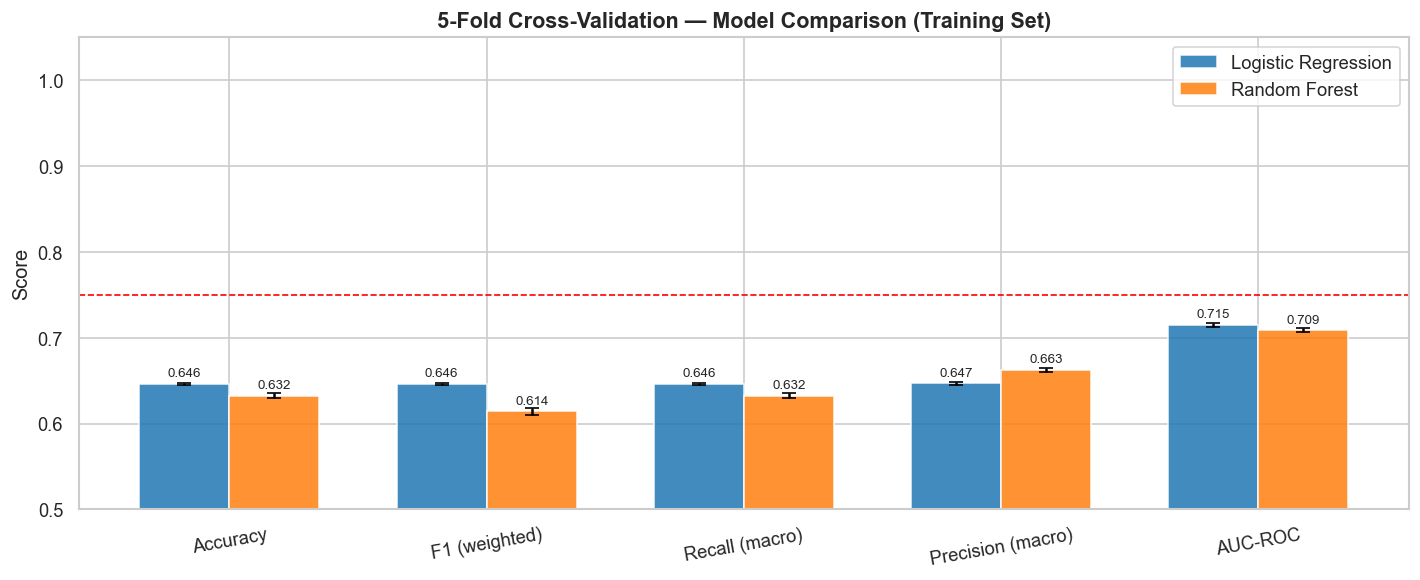

Error bars show standard deviation across the 5 folds.
Red dashed line = 0.75 accuracy target.


In [57]:
#Visualise Cross-Validation Results
metrics = cv_results['Metric'].tolist()
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars_lr = ax.bar(x - width/2, cv_results['LR Mean'], width,
                 yerr=cv_results['LR Std'], capsize=4,
                 label='Logistic Regression', color='#1f77b4', alpha=0.85)
bars_rf = ax.bar(x + width/2, cv_results['RF Mean'], width,
                 yerr=cv_results['RF Std'], capsize=4,
                 label='Random Forest', color='#ff7f0e', alpha=0.85)

ax.set_title('5-Fold Cross-Validation — Model Comparison (Training Set)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Score')
ax.set_xticks(x)
ax.set_xticklabels(metrics, rotation=10)
ax.set_ylim(0.5, 1.05)
ax.legend()
ax.axhline(0.75, color='red', linestyle='--', linewidth=1, label='Target (0.75)')

for bar in bars_lr:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars_rf:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()
print("Error bars show standard deviation across the 5 folds.")
print("Red dashed line = 0.75 accuracy target.")

In [58]:
#Train Final Models on Full Training Set
#After cross-validation confirms stability,
#Fit on the FULL training set before evaluating on the unseen test set.

print("Fitting Logistic Regression on full training set")
pipeline_lr.fit(X_train, y_train)
print("Done.")

print("Fitting Random Forest on full training set")
pipeline_rf.fit(X_train, y_train)
print("Done.")

print("\nBoth models trained on full training set")

Fitting Logistic Regression on full training set
Done.
Fitting Random Forest on full training set
Done.

Both models trained on full training set


In [59]:
#Evaluation on Unseen Test Set
#The test set has NOT been seen by any model until this point.
#This gives an honest measure of performance on new data.

y_pred_lr = pipeline_lr.predict(X_test)
y_pred_rf = pipeline_rf.predict(X_test)

y_prob_lr = pipeline_lr.predict_proba(X_test)[:, 1]
y_prob_rf = pipeline_rf.predict_proba(X_test)[:, 1]

print("LOGISTIC REGRESSION — Test Set Performance")
print()
print(classification_report(y_test, y_pred_lr,
      target_names=['Low Priority (0)', 'High Priority (1)']))

print()
print("RANDOM FOREST — Test Set Performance")
print()
print(classification_report(y_test, y_pred_rf,
      target_names=['Low Priority (0)', 'High Priority (1)']))

print("Interpretation:")
print("Precision — of all records flagged High Priority, what % were actually High Priority.")
print("Recall — of all actual High Priority records, what % did the model catch.")
print("In a safety context, Recall is the most important — missing an urgent case is dangerous.")

LOGISTIC REGRESSION — Test Set Performance

                   precision    recall  f1-score   support

 Low Priority (0)       0.65      0.64      0.64      7151
High Priority (1)       0.64      0.66      0.65      7151

         accuracy                           0.65     14302
        macro avg       0.65      0.65      0.65     14302
     weighted avg       0.65      0.65      0.65     14302


RANDOM FOREST — Test Set Performance

                   precision    recall  f1-score   support

 Low Priority (0)       0.74      0.41      0.53      7151
High Priority (1)       0.59      0.85      0.70      7151

         accuracy                           0.63     14302
        macro avg       0.66      0.63      0.61     14302
     weighted avg       0.66      0.63      0.61     14302

Interpretation:
Precision — of all records flagged High Priority, what % were actually High Priority.
Recall — of all actual High Priority records, what % did the model catch.
In a safety context, Recall

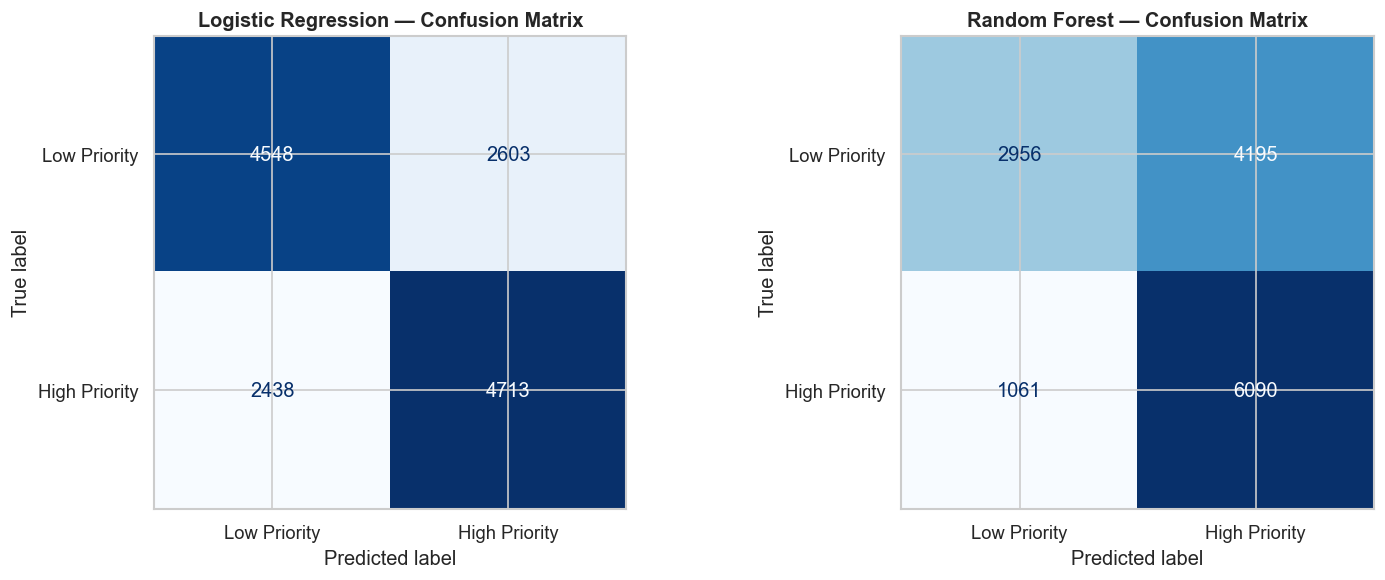

False Negatives (High predicted as Low) are the most critical error in a safety context.
A missed High Priority incident could delay response and put workers at risk.


In [60]:
#Confusion Matrices
#True Positive  (TP) — correctly flagged High Priority
#True Negative  (TN) — correctly flagged Low Priority
#False Positive (FP) — Low Priority wrongly flagged as High (false alarm)
#False Negative (FN) — High Priority MISSED — most dangerous error for safety

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_pred, title in zip(axes,
                              [y_pred_lr, y_pred_rf],
                              ['Logistic Regression', 'Random Forest']):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Low Priority', 'High Priority'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{title} — Confusion Matrix', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("False Negatives (High predicted as Low) are the most critical error in a safety context.")
print("A missed High Priority incident could delay response and put workers at risk.")

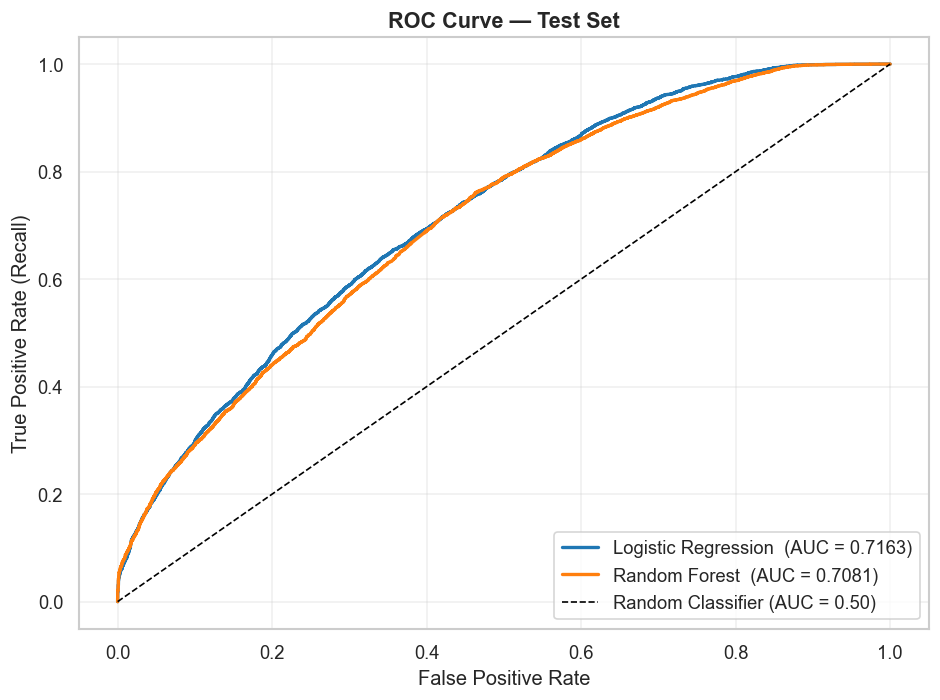

Logistic Regression AUC : 0.7163
Random Forest AUC : 0.7081
AUC = probability that model ranks a random High Priority case above a random Low Priority case.


In [61]:
#ROC Curves
#Plots True Positive Rate vs False Positive Rate at every threshold.
#AUC closer to 1.0 = better separation between High and Low Priority.
#Random classifier = AUC 0.50 (dashed line).

fig, ax = plt.subplots(figsize=(8, 6))

for y_prob, label, color in [
    (y_prob_lr, 'Logistic Regression', '#1f77b4'),
    (y_prob_rf, 'Random Forest', '#ff7f0e')
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f'{label}  (AUC = {auc:.4f})', color=color, linewidth=2)

ax.plot([0,1], [0,1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.50)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('ROC Curve — Test Set', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Logistic Regression AUC : {roc_auc_score(y_test, y_prob_lr):.4f}")
print(f"Random Forest AUC : {roc_auc_score(y_test, y_prob_rf):.4f}")
print("AUC = probability that model ranks a random High Priority case above a random Low Priority case.")

In [62]:
#Final Model Comparison Summary
lr_auc = roc_auc_score(y_test, y_prob_lr)
rf_auc = roc_auc_score(y_test, y_prob_rf)

summary = pd.DataFrame({
    'Metric': ['Accuracy', 'F1 (weighted)', 'Recall — High Priority',
               'Precision — High Priority', 'AUC-ROC'],
    'Logistic Regression': [
        accuracy_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_lr, average='weighted'),
        recall_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_lr),
        lr_auc
    ],
    'Random Forest': [
        accuracy_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf, average='weighted'),
        recall_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf),
        rf_auc
    ]
})

print("Final Test Set Performance Summary")
print()
print(summary.to_string(index=False, float_format='{:.4f}'.format))

best_model    = 'Random Forest' if rf_auc > lr_auc else 'Logistic Regression'
best_pipeline = pipeline_rf if rf_auc > lr_auc else pipeline_lr
print(f"\nBest model based on AUC-ROC: {best_model}")
print("\nModel Selection:")
print(f"{best_model} selected as the production model based on highest AUC-ROC.")


Final Test Set Performance Summary

                   Metric  Logistic Regression  Random Forest
                 Accuracy               0.6475         0.6325
            F1 (weighted)               0.6475         0.6140
   Recall — High Priority               0.6591         0.8516
Precision — High Priority               0.6442         0.5921
                  AUC-ROC               0.7163         0.7081

Best model based on AUC-ROC: Logistic Regression

Model Selection:
Logistic Regression selected as the production model based on highest AUC-ROC.


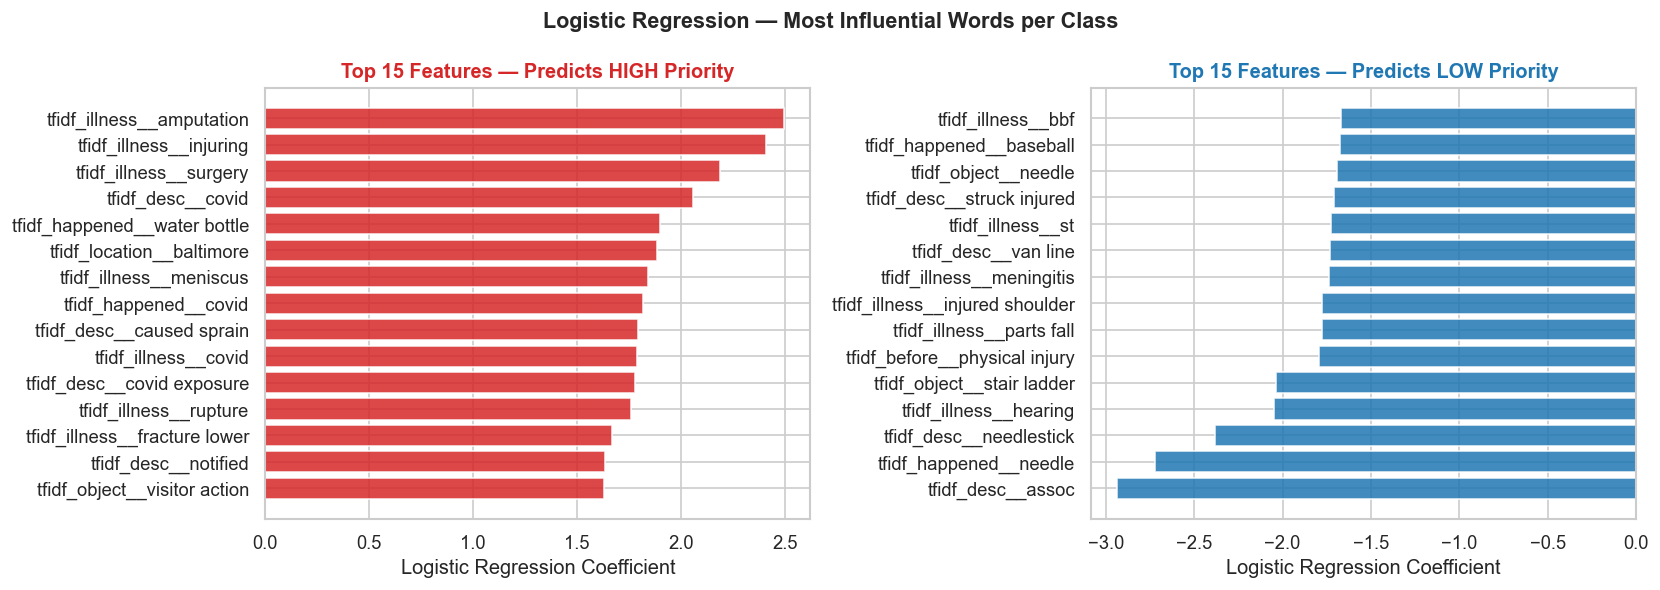

Positive coefficients push a record toward High Priority.
Negative coefficients push a record toward Low Priority.
This chart confirms the model is learning genuine safety-relevant vocabulary.


In [63]:
#Top Predictive Features — Logistic Regression
#LR assigns a coefficient to each TF-IDF feature.
#Positive = pushes toward High Priority
#Negative = pushes toward Low Priority
#This makes the model interpretable — we can see exactly which words matter most.

lr_clf = pipeline_lr.named_steps['clf']
feature_names_out = pipeline_lr.named_steps['features'].get_feature_names_out()
coef = lr_clf.coef_[0]

top_n = 15
top_high = np.argsort(coef)[::-1][:top_n]
top_low  = np.argsort(coef)[:top_n]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(feature_names_out[top_high][::-1], coef[top_high][::-1],
             color='#d62728', alpha=0.85)
axes[0].set_title('Top 15 Features — Predicts HIGH Priority',
                  fontsize=12, fontweight='bold', color='#d62728')
axes[0].set_xlabel('Logistic Regression Coefficient')

axes[1].barh(feature_names_out[top_low], coef[top_low],
             color='#1f77b4', alpha=0.85)
axes[1].set_title('Top 15 Features — Predicts LOW Priority',
                  fontsize=12, fontweight='bold', color='#1f77b4')
axes[1].set_xlabel('Logistic Regression Coefficient')

plt.suptitle('Logistic Regression — Most Influential Words per Class',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Positive coefficients push a record toward High Priority.")
print("Negative coefficients push a record toward Low Priority.")
print("This chart confirms the model is learning genuine safety-relevant vocabulary.")

In [64]:
# Save Best Model to disk
# The full pipeline (ColumnTransformer + classifier) is saved with joblib.
# This file is loaded by the Streamlit app to make predictions.
# It contains everything — TF-IDF vectorisers, scaler, and classifier.

import os

# Create the models folder if it doesn't exist
os.makedirs('models', exist_ok=True)

# Save the best pipeline
joblib.dump(best_pipeline, 'models/best_model.joblib')

print(f"Best model    : {best_model}")
print(f"Saved to      : models/best_model.joblib")
print(f"File size     : {os.path.getsize('models/best_model.joblib') / 1e6:.1f} MB")
print()
print("The models/ folder has been created in the same location as this notebook.")
print("Copy the entire models/ folder into your SafeReportAI project folder.")

Best model    : Logistic Regression
Saved to      : models/best_model.joblib
File size     : 10.5 MB

The models/ folder has been created in the same location as this notebook.
Copy the entire models/ folder into your SafeReportAI project folder.
